In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

In [23]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')


train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.head()

Training data shape: (123279, 1688)
Training date range: 2018-10-17 to 2023-04-09
Validation data shape: (26357, 1683)
Validation date range: 2023-10-25 to 2024-04-14
Test data shape: (26264, 1683)
Test date range: 2024-10-23 to 2025-04-13


Unnamed: 0  Unnamed: 0.2      PLAYER_NAME  PLAYER_ID    MATCHUP  \
0           0          47.0         Alex Len     203458  ATL @ NYK   
1           1          49.0   Alex Poythress    1627816  ATL @ NYK   
2           2          48.0  DeAndre' Bembry    1627761  ATL @ NYK   
3           3          90.0     Jaylen Adams    1629121  ATL @ NYK   
4           4          87.0       Jeremy Lin     202391  ATL @ NYK   

  TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0               ATL  1610612737              NYK          0  21800007   
1               ATL  1610612737              NYK          0  21800007   
2               ATL  1610612737              NYK          0  21800007   
3               ATL  1610612737              NYK          0  21800007   
4               ATL  1610612737              NYK          0  21800007   

    GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  FTM  \
0  2018-10-17  L    7    2    4    3    6    0.50     0     2    0.000    1   
1  2018-10-17  L    9    0    2    4    8    0.50     1     3    0.333    0   
2  2018-10-17  L    2    4    4    1    4    0.25     0     0      NaN    0   
3  2018-10-17  L    0    1    1    0    1    0.00     0     1    0.000    0   
4  2018-10-17  L    8    1    5    3    6    0.50     0     2    0.000    2   

   FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0    2     0.5     2     2    0    1    3         -14         14.8   
1    1     0.0     1     1    1    0    3         -21         11.4   
2    0     NaN     0     4    2    0    2         -12         16.8   
3    0     NaN     0     1    0    0    0           4          2.7   
4    2     1.0     0     5    1    0    2          -5         16.5   

   POINT_PER_SHOT     EFG START_POSITION  COMMENT  OFF_RATING  E_OFF_RATING  \
0           1.017  0.5000              C      NaN        92.3          92.3   
1           1.066  0.5625            NaN      NaN        68.0          68.0   
2           0.500  0.2500            NaN      NaN        80.7          80.7   
3           0.000  0.0000            NaN      NaN        80.0          80.0   
4           1.163  0.5000            NaN      NaN        66.7          66.7   

   DEF_RATING  E_DEF_RATING  NET_RATING  OREB_PCT  DREB_PCT  REB_PCT  AST_PCT  \
0       121.6         121.6       -29.3     0.095     0.074    0.083    0.133   
1       110.0         110.0       -42.0     0.045     0.050    0.048    0.000   
2       100.0         100.0       -19.3     0.000     0.129    0.074    0.235   
3        40.0          40.0        40.0     0.000     0.200    0.100    0.250   
4        77.1          77.1       -10.5     0.000     0.278    0.156    0.143   

   EFG_PCT  AST_TOV  USG_PCT  TS_PCT  E_PACE    PACE    PIE  POSS  PACE_PER40  \
0    0.500     0.67    0.179   0.509  115.29  115.29  0.016  52.0       96.07   
1    0.563     0.00    0.208   0.533  115.84  115.84 -0.007  50.0       96.53   
2    0.250     2.00    0.095   0.250  118.39  118.39  0.089  57.0       98.66   
3    0.000     0.00    0.083   0.000  112.06  112.06  0.222  10.0       93.39   
4    0.500     0.50    0.257   0.581  119.12  119.12  0.282  33.0       99.27   

   E_USG_PCT    MIN   SPD  DIST  ORBC  DRBC   RBC  TCHS  SAST  FTAST  PASS  \
0      0.179  21.45  4.50  1.74   7.0   9.0  16.0  40.0   0.0    0.0  31.0   
1      0.208  20.72  4.76  1.77   4.0   2.0   5.0  39.0   0.0    0.0  29.0   
2      0.095  23.32  4.46  1.90   1.0   7.0   8.0  26.0   0.0    1.0  18.0   
3      0.083   4.28  4.14  0.32   0.0   2.0   2.0   4.0   0.0    0.0   3.0   
4      0.257  13.70  4.71  1.14   1.0   5.0   5.0  32.0   0.0    0.0  21.0   

   CFGM  CFGA  CFG_PCT  UFGM  UFGA  UFG_PCT  DFGM  DFGA  DFG_PCT  PTS_OFF_TOV  \
0   3.0   4.0    0.750   0.0   2.0    0.000   1.0   5.0    0.200          2.0   
1   2.0   4.0    0.500   2.0   4.0    0.500   0.0   1.0    0.000          0.0   
2   1.0   4.0    0.250   0.0   0.0    0.000   2.0   3.0    0.667          0.0   
3   0

In [24]:
top_features = [
    # playerContext 
    # 'HOME_GAME',
    'STARTING', 
    'PLAYER_IS_TEAM_STAR',
    'TEAM_STAR_OUT',
    'NUM_USUAL_STARTERS_PRESENT',
    # 'IS_BACK_TO_BACK',
    # 'PLAYER_DAYS_REST',

    # playerScoring 
    'PTS_ROLLING_AVG_40',
    'PTS_ROLLING_AVG_25',
    'PTS_ROLLING_AVG_15',
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_7',
    'PTS_AVG_TO_DATE',
    'PTS_WITHOUT_STAR',
    'PTS_PER_36_WITHOUT_STAR',
    'PTS_PER_MIN_X_USG',
    'EXPECTED_USAGE_MIN',
    'FGA_ROLLING_AVG_40',
    'FGA_ROLLING_AVG_25',
    'FGA_ROLLING_AVG_15',
    'FGA_ROLLING_AVG_10',
    'FGA_ROLLING_AVG_7',
    'FGA_ROLLING_AVG_5',
    'FGA_LAG_1',
    'FGA_WITHOUT_STAR',
    'FG3A_ROLLING_AVG_5',
    'FG3A_ROLLING_AVG_7',
    'FG3A_ROLLING_AVG_10',
    'FG3A_ROLLING_AVG_15',
    'FG3A_WITHOUT_STAR',
    'UFGA_ROLLING_AVG_15',
    'UFGA_ROLLING_AVG_7',
    'FTM_ROLLING_AVG_15',
    'FTM_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_25',
    'E_USG_PCT_ROLLING_AVG_5',
    'E_USG_PCT_ROLLING_AVG_7',
    'E_USG_PCT_ROLLING_AVG_10',
    'E_USG_PCT_ROLLING_AVG_25',
    'E_USG_PCT_ROLLING_AVG_15',
    'USG_PCT_ROLLING_AVG_15',
    'USG_PCT_ROLLING_AVG_10',
    'USG_PCT_ROLLING_AVG_7',
    'USG_PCT_WITHOUT_STAR',
    'USG_PCT_AVG_TO_DATE',
    'USG_X_POSS',
    'USG_X_TEAM_OFF',
    # 'TS_PCT_ROLLING_AVG_10',
    'PIE_WITHOUT_STAR',
    'PLAYER_PAINT_X_OPP_PAINT_DEF_RECENT',
    'MIN_LAG_1',
    'MIN_AVG_TO_DATE',
    'MIN_ROLLING_AVG_10',
    'MIN_VOLATILITY_10_TO_DATE',
    'PTS_STD_LAST_40',

    # teamContext 
    'TEAM_PTS_ROLLING_AVG_5',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_OFF_RATING_ROLLING_AVG_5',
    'TEAM_DEF_RATING_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_5',
    'TEAM_STAR_OUT_X_USG',
    'TEAM_STAR_OUT_X_PTS',
    'STARTER_X_TEAM_OFF',

    # playerVsOpp 
    # 'OPP_DEF_RATING_AVG_TO_DATE',
    # 'OPP_PACE_AVG_TO_DATE',
    # 'PLAYER_PAINT_X_OPP_PAINT_DEF',  # Keep it here
    # 'PTS_PER_MIN_X_OPP_DEF_RATING',
    # 'USG_X_OPP_DEF_RATING',

    # playerZones 
    'percentagePointsPaint_AVG_TO_DATE',
    'percentagePointsPaint_ROLLING_AVG_25',
    'percentagePointsPaint_ROLLING_AVG_40',
    'percentagePointsPaint_ROLLING_AVG_5',
    # 'percentagePointsPaint_STD_LAST_40',
    'percentagePoints2pt_ROLLING_AVG_15',
    'percentagePointsPaint_EXPANDING_VOLATILITY_TO_DATE',
    'FTM_AVG_TO_DATE',
    
    # playerHomeAway 
    'PLAYER_AWAY_AVG_percentagePointsPaint_TO_DATE',
    'PLAYER_AWAY_AVG_PTS_TO_DATE',

    # playerMatchup 
    # 'MATCHUP_AVG_PTS_LAST_5_TO_DATE',
    # 'MATCHUP_AVG_USG_PCT_LAST_5_TO_DATE',
    'PFD_ROLLING_AVG_10',
    'RBC_ROLLING_AVG_40'
]

In [4]:
newFeatures = train_df.columns[train_df.columns.tolist().index('STARTING'):].tolist()

In [5]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

def select_features_xgb_importance(
    X,
    y,
    top_n=40,
    n_runs=5,
    include_context=True,
    validate_permutation=False
):
    feature_scores = np.zeros(X.shape[1])

    # Run multiple XGBoost fits to stabilize importance
    for seed in range(n_runs):
        xgb = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42 + seed,
            verbosity=0
        )
        xgb.fit(X, y)
        feature_scores += xgb.feature_importances_

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_scores / n_runs
    }).sort_values('importance', ascending=False)

    top_features = importance_df.head(top_n)['feature'].tolist()

    # Add context features that improve stability and interpretability
    if include_context:
        context_features = [
            'HOME_GAME', 'TEAM_STAR_OUT', 'IS_BACK_TO_BACK', 'PLAYER_DAYS_REST',
            'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE', 
            'TEAM_PACE_AVG_TO_DATE', 'TEAM_OFF_RATING_AVG_TO_DATE'
            'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_10', 'MIN_LAG_1', 'MIN_LAG_2','MIN_AVG_TO_DATE', 'MIN_VOLATILITY_10_TO_DATE'
        ]
        for f in context_features:
            if f in X.columns and f not in top_features:
                top_features.append(f)

    # Optional: Permutation importance validation
    if validate_permutation:
        print("Validating with permutation importance...")
        model = XGBRegressor(n_estimators=300, random_state=42, verbosity=0)
        model.fit(X[top_features], y)
        perm = permutation_importance(model, X[top_features], y, n_repeats=5, random_state=42)
        perm_df = pd.DataFrame({
            'feature': top_features,
            'perm_importance': perm.importances_mean
        }).sort_values('perm_importance', ascending=False)

        # Filter out weak features
        perm_df = perm_df[perm_df['perm_importance'] > 0]
        top_features = perm_df['feature'].tolist()

    print(f"Selected {len(top_features)} total features")
    print("Top 10 most important:")
    for i, f in enumerate(top_features[:10]):
        print(f"{i+1}. {f}")

    return X[top_features], top_features


In [6]:
# train_df['USG_X_MIN_5'] = (
#     train_df['USG_PCT_ROLLING_AVG_5'] * train_df['MIN_ROLLING_AVG_5']
#     if 'USG_PCT_ROLLING_AVG_5' in train_df.columns and 'MIN_ROLLING_AVG_5' in train_df.columns
#     else 0
# )
# train_df['PACE_X_MIN_5'] = (
#     train_df['PACE_ROLLING_AVG_5'] * train_df['MIN_ROLLING_AVG_5']
#     if 'PACE_ROLLING_AVG_5' in train_df.columns and 'MIN_ROLLING_AVG_5' in train_df.columns
#     else 0
# )


# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=60,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=True,     # adds game context
#     validate_permutation=True # prunes noise
# )

# XGBOOST MODEL

In [25]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 5.302280387971515, 'MAE': 4.0006167121487595, 'R2': 0.652290940284729, 'best_iteration': 780}
Test metrics: {'RMSE': 5.456684488837839, 'MAE': 4.131030209083507, 'R2': 0.6152445077896118}


In [26]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                       TOP_FEATURES  TOP_IMPORTANCE                                    BOTTOM_FEATURES  BOTTOM_IMPORTANCE
                 PTS_ROLLING_AVG_15        0.238228                             TEAM_AST_ROLLING_AVG_5           0.003154
                 PTS_ROLLING_AVG_40        0.141930                            E_USG_PCT_ROLLING_AVG_7           0.003128
                 PTS_ROLLING_AVG_25        0.114503                             USG_PCT_ROLLING_AVG_15           0.002990
                 EXPECTED_USAGE_MIN        0.098957                  percentagePointsPaint_AVG_TO_DATE           0.002965
                    PTS_AVG_TO_DATE        0.037867                            E_USG_PCT_ROLLING_AVG_5           0.002813
                 PTS_ROLLING_AVG_10        0.031928                                    FTM_AVG_TO_DATE           0.002701
PLAYER_PAINT_X_OPP_PAINT_DEF_RECENT        0.026832                      TEAM_DEF_RATING_ROLLING_AVG_5

In [27]:
joblib.dump(xgbModel, 'Models/xgbPTSModelNoOppStats.pkl')
joblib.dump(top_features, 'Models/topPTSfeaturesNoOppStats.pkl')

['Models/topPTSfeaturesNoOppStats.pkl']

In [29]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN
0,5,29.324167,24.324167,Tyrese Maxey,PHI vs. GSW,126,119.0,1,39.82
1,5,26.342522,21.342522,Brandon Ingram,NOP vs. OKC,109,119.0,1,18.90
2,3,23.755096,20.755096,Desmond Bane,MEM @ OKC,104,125.0,1,31.80
3,9,29.136740,20.136740,Anthony Edwards,MIN vs. BKN,117,91.0,1,30.52
4,3,22.908390,19.908390,Stephen Curry,GSW vs. HOU,96,106.0,1,32.67
5,8,26.933184,18.933184,Ja Morant,MEM vs. SAC,115,110.0,1,27.82
6,11,29.690002,18.690002,Cade Cunningham,DET vs. OKC,107,113.0,1,29.02
7,0,18.320824,18.320824,Anfernee Simons,POR vs. LAC,89,118.0,1,29.87
8,0,18.125366,18.125366,Miles Norris,BOS vs. PHI,123,105.0,0,4.02
9,0,17.983410,17.983410,Bobi Klintman,DET @ BKN,113,98.0,0,4.28


C:\Users\alexg\AppData\Local\Temp\ipykernel_24816\1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_24816\1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


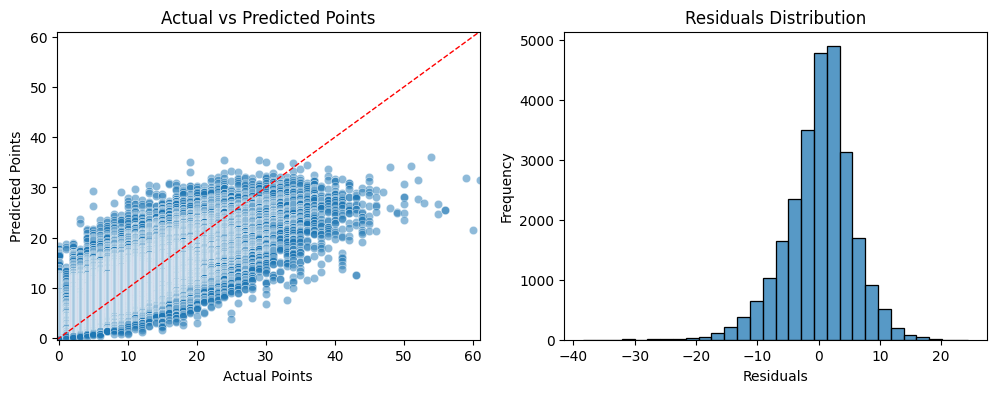

In [30]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

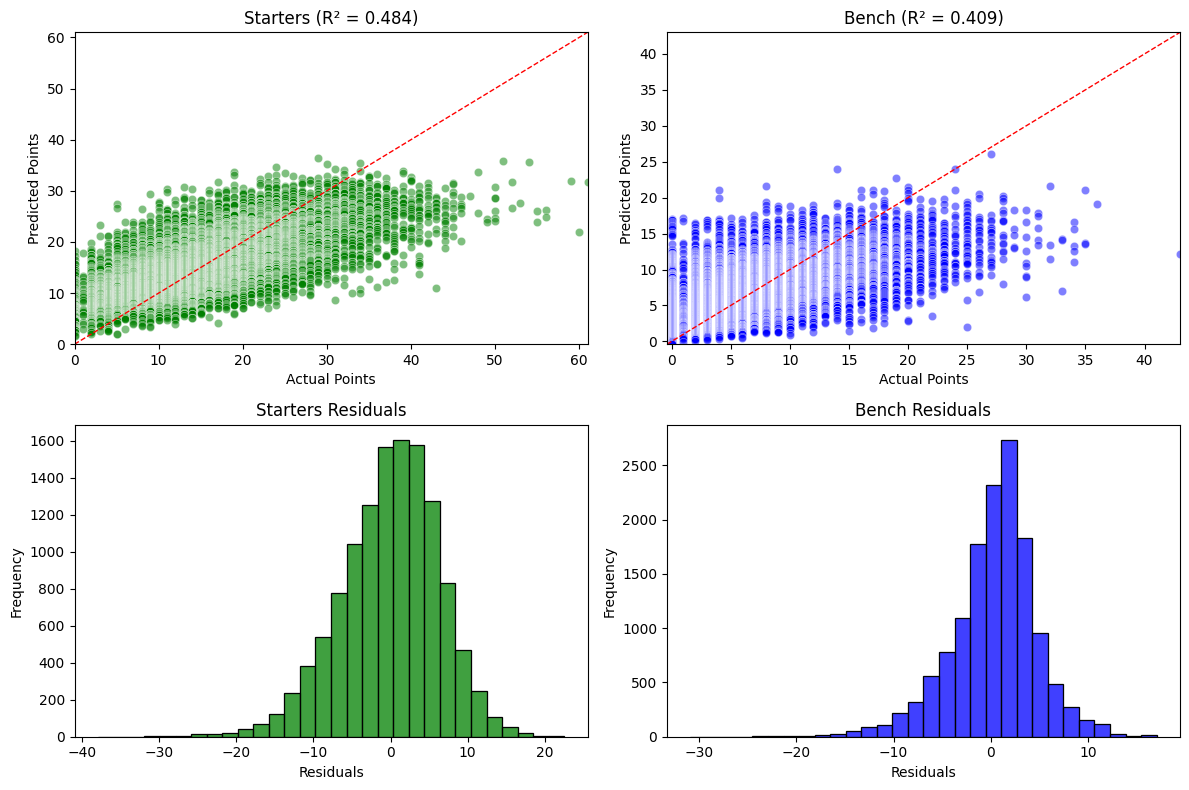

In [31]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


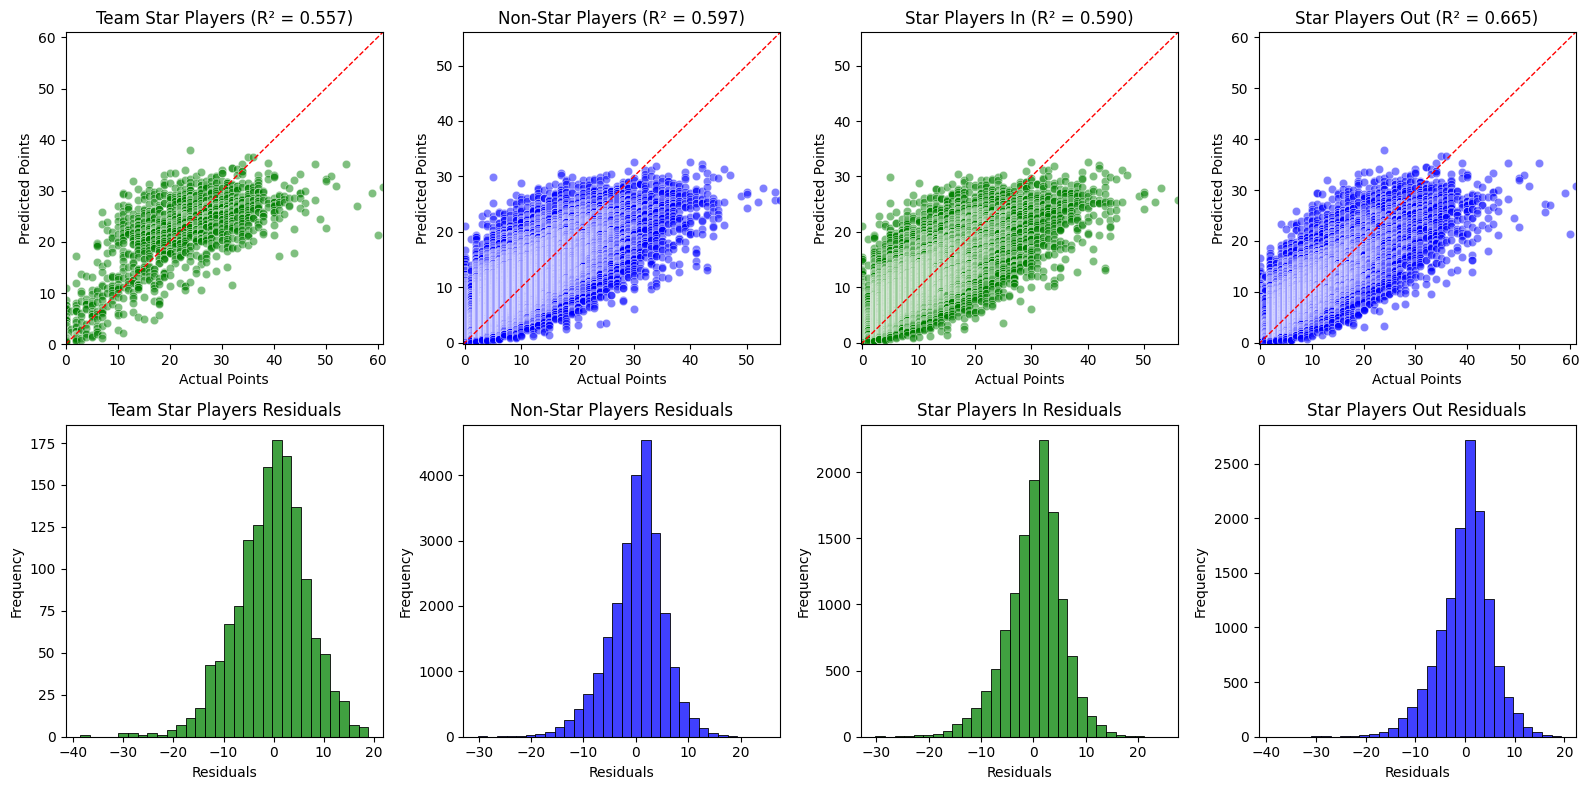

In [ ]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

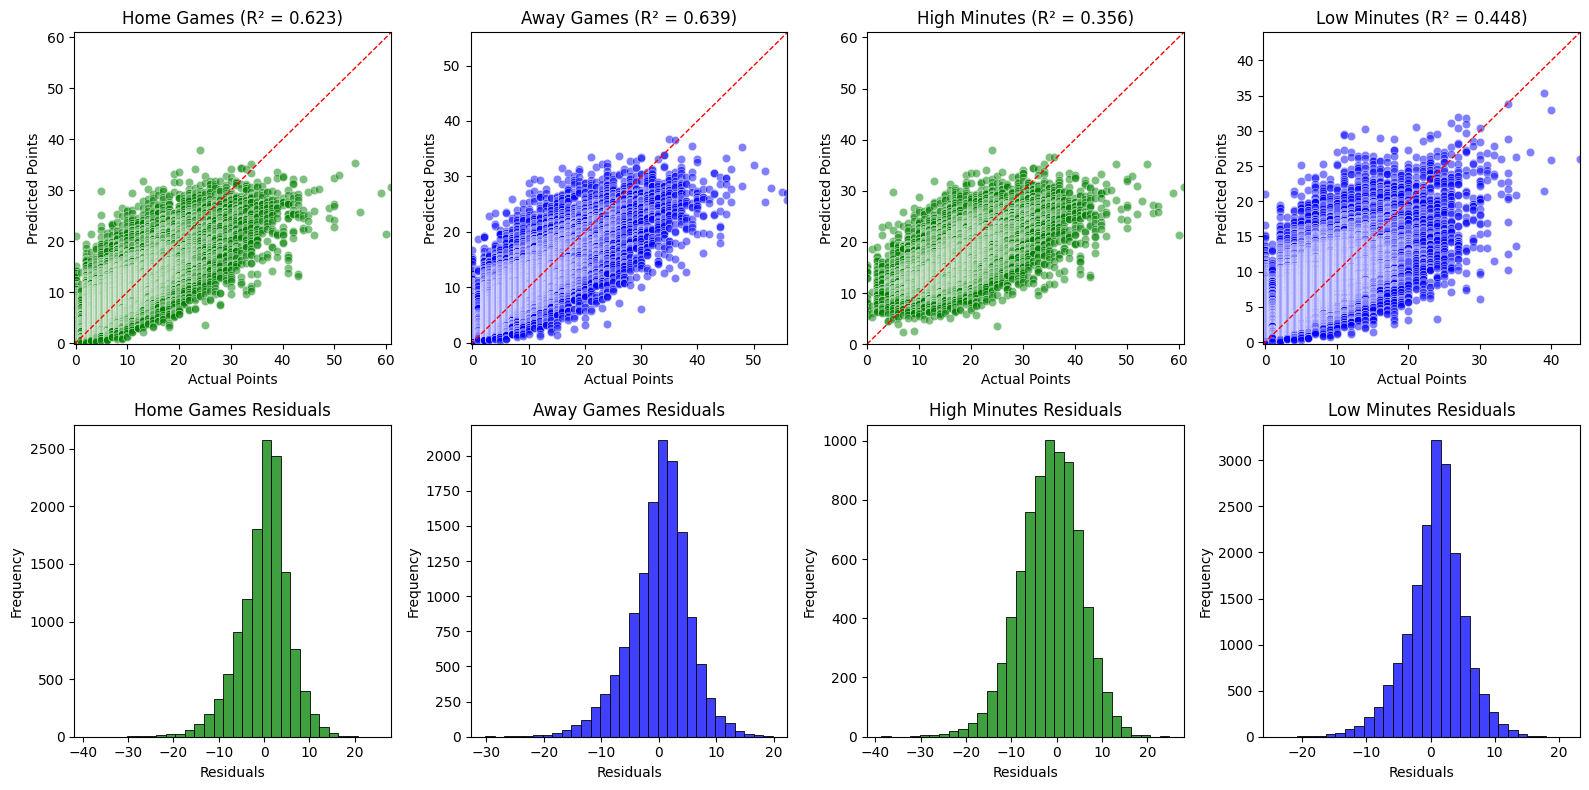

In [ ]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()